In [12]:
import pandas as pd
import numpy as np
import os

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Create output folder
os.makedirs("output", exist_ok=True)

# Set style
sns.set(style="whitegrid")

In [14]:
sample_info = pd.read_csv("input/sample_info.tsv", sep="\t")
sample_info = sample_info[["Sample ID", "CF ID", "Sex", "TP"]]

meta = pd.read_csv("input/meta.tsv", sep="\t")
quant = pd.read_csv("input/plasma_prot_quant.tsv", sep="\t")

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_67070/1551548942.py:5: DtypeWarning: Columns (0: [254] XCHEJF1-254_20250824_plasma_S254_250ng_41p5min_DIA_r2.raw.PG.MS1Quantity, 1: [254] XCHEJF1-254_20250824_plasma_S254_250ng_41p5min_DIA_r2.raw.PG.MS2Quantity) have mixed types. Specify dtype option on import or set low_memory=False.
  quant = pd.read_csv("input/plasma_prot_quant.tsv", sep="\t")


In [15]:
# Build mapping: R.FileName → CF ID
mapping = dict(zip(meta["R.FileName"], meta["Sample ID"]))

# Extract abundance columns
quant_cols = quant.columns[1:]  # excluding PG.Genes

col_to_cf = {}

for col in quant_cols:
    for rfile, cfid in mapping.items():
        if rfile in col:
            col_to_cf[col] = cfid
            break

# Keep only mapped columns
quant_filtered = quant[list(col_to_cf.keys())]

# Rename columns to CF IDs
quant_filtered = quant_filtered.rename(columns=col_to_cf)

In [16]:
# Transpose
X = quant_filtered.T

# Remove potential duplicate CF IDs (keep first)
X = X[~X.index.duplicated(keep='first')]

# Merge with sample_info
data = X.merge(sample_info, left_index=True, right_on="CF ID")
data = data.set_index("CF ID")
data


,0,1,2,3,4,5,6,7,8,9,...,2062,2063,2064,2065,2066,2067,2068,Sample ID,Sex,TP
CF ID,,,,,,,,,,,,,,,,,,,,,
XCHEJF_001,1,8,2,0,0,3,3,1,0,1,...,0,2,42,430,8,5,0,SWE001,M,T0
XCHEJF_002,0,8,2,0,0,1,5,1,0,1,...,0,2,40,407,9,2,0,SWE001,NaN,T1
XCHEJF_003,0,7,2,0,0,2,2,1,0,1,...,0,1,37,427,8,2,0,SWE002,M,T0
XCHEJF_004,1,10,1,0,0,0,6,1,0,1,...,0,1,38,430,8,3,0,SWE002,NaN,T1
XCHEJF_005,0,6,1,0,0,3,5,1,0,1,...,0,1,42,438,8,5,0,SWE004,M,T0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XCHEJF_241,0,6,1,0,4,0,3,1,0,1,...,0,3,46,454,6,2,0,ITA081,F,T0
XCHEJF_243,0,9,3,0,0,1,2,1,0,2,...,0,3,47,434,9,3,0,ITA083,M,T0
XCHEJF_244,0,7,3,0,0,0,3,1,0,2,...,0,2,46,425,9,3,0,ITA085,F,T0


__PCA__

In [17]:
features = data.drop(columns=["Sample ID", "TP", "Sex"])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=data.index)

# Add metadata
pca_df = pd.concat([pca_df, data[["Sample ID", "TP", "Sex"]]], axis=1)

# Extract Country from Sample ID
pca_df["Country"] = pca_df["Sample ID"].str[:3]

# Compute global axis limits
x_min, x_max = pca_df["PC1"].min(), pca_df["PC1"].max()
y_min, y_max = pca_df["PC2"].min(), pca_df["PC2"].max()

# Add small padding
x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

x_limits = (x_min - x_pad, x_max + x_pad)
y_limits = (y_min - y_pad, y_max + y_pad)


_Country_

In [18]:
palette = ["#9ecae1", "#fc9272", "#a1d99b", "#bcbddc", "#fa9fb5"]

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_67070/2670697354.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(


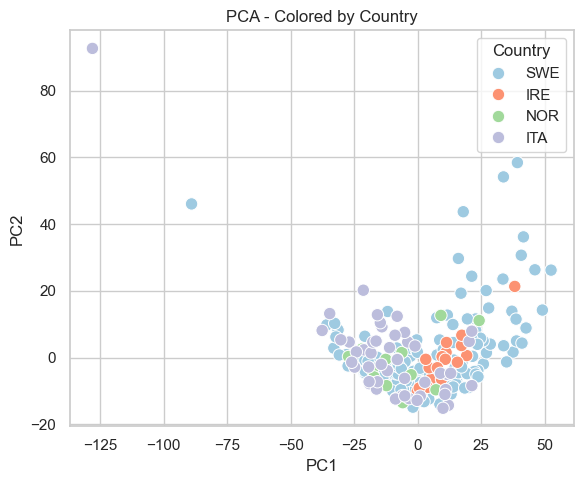

In [19]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Country",
    palette=palette,
    s=80
)

plt.xlim(x_limits)
plt.ylim(y_limits)

plt.title("PCA - Colored by Country")
plt.tight_layout()

plt.savefig("output/PCA_country.png", dpi=300)
plt.savefig("output/PCA_country.pdf")
plt.show()

_Timepoint_

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_67070/852804798.py:3: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


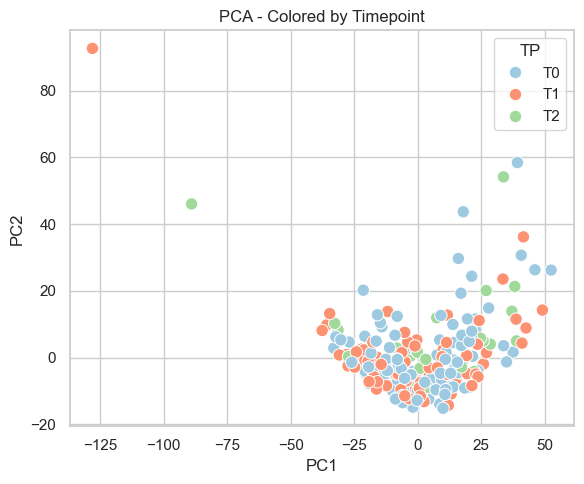

In [20]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="TP",
    palette=palette,
    s=80
)

plt.xlim(x_limits)
plt.ylim(y_limits)

plt.title("PCA - Colored by Timepoint")
plt.tight_layout()

plt.savefig("output/PCA_timepoint.png", dpi=300)
plt.savefig("output/PCA_timepoint.pdf")
plt.show()

_Sex_

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_67070/265911886.py:3: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.scatterplot(


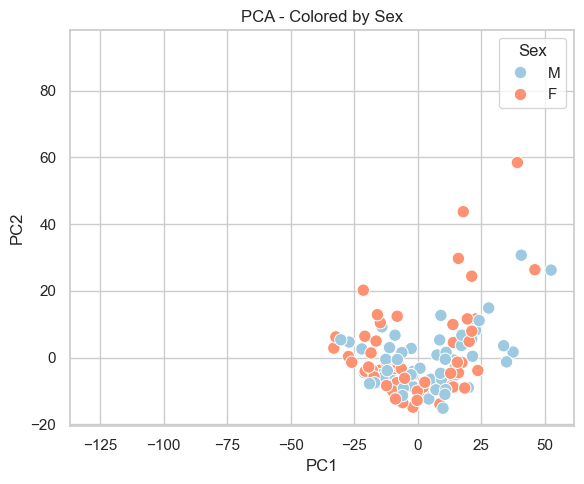

In [21]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Sex",
    palette=palette,
    s=80
)

plt.xlim(x_limits)
plt.ylim(y_limits)

plt.title("PCA - Colored by Sex")
plt.tight_layout()

plt.savefig("output/PCA_sex.png", dpi=300)
plt.savefig("output/PCA_sex.pdf")
plt.show()

_Explained variances_

In [22]:
print("Explained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

Explained variance:
PC1: 20.23%
PC2: 7.35%
